# Pipeline demo: Boolean model → STG → attractors → MaBoSS

In [1]:
import itertools, os
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
import mpbn, maboss

os.makedirs("figures", exist_ok=True)
GREEN, RED = "#2a9d8f", "#e63946"
PHENO = {"Autophagy": "#2a9d8f", "Apoptosis": "#e63946", "Proliferation": "#457b9d", "transient": "#d9d9d9"}

## 1. Boolean model

In [2]:
rules = {
    "Nutrients": "Nutrients",
    "MTOR":      "Nutrients",
    "ULK1":      "!MTOR",
    "BECN1":     "ULK1 & !CASP3",
    "CASP3":     "!MTOR & !BECN1",
}
with open("toy_model.bnet", "w") as f:
    f.write("targets, factors\n" + "".join(f"{k}, {v}\n" for k, v in rules.items()))
nodes = list(rules)
print(open("toy_model.bnet").read())

targets, factors
Nutrients, Nutrients
MTOR, Nutrients
ULK1, !MTOR
BECN1, ULK1 & !CASP3
CASP3, !MTOR & !BECN1



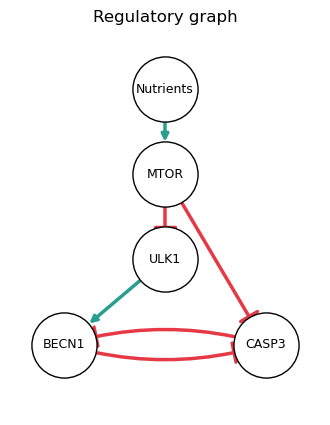

In [3]:
edges = [("Nutrients","MTOR",+1), ("MTOR","ULK1",-1), ("ULK1","BECN1",+1),
         ("CASP3","BECN1",-1), ("BECN1","CASP3",-1), ("MTOR","CASP3",-1)]
G = nx.DiGraph([(s, t, {"sign": w}) for s, t, w in edges])
pos = {"Nutrients": (0, 2), "MTOR": (0, 1), "ULK1": (0, 0), "BECN1": (-0.8, -1), "CASP3": (0.8, -1)}

fig, ax = plt.subplots(figsize=(4, 5))
nx.draw_networkx_nodes(G, pos, node_size=2200, node_color="white", edgecolors="black", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
for s, t, d in G.edges(data=True):
    pos_e = d["sign"] > 0
    nx.draw_networkx_edges(G, pos, [(s, t)], node_size=2200, width=2.5, ax=ax,
                           edge_color=GREEN if pos_e else RED,
                           arrowstyle="-|>" if pos_e else "|-|,widthA=0,widthB=0.7",
                           connectionstyle="arc3,rad=0.15" if {s, t} == {"BECN1", "CASP3"} else "arc3")
ax.set_title("Regulatory graph"); ax.axis("off"); ax.margins(0.2)
fig.savefig("figures/1_regulatory_graph.png", dpi=300, bbox_inches="tight")

## 2. State transition graph (asynchronous, whole system)

All 5 nodes are free, giving 2⁵ = 32 states. `Nutrients` is an input (`Nutrients = Nutrients`), so it never changes and the
STG splits into two disconnected halves, one for `Nutrients = 0` and one for `Nutrients = 1`.

In [4]:
def evaluate(rule, s):
    expr = rule.replace("!", " not ").replace("&", " and ").replace("|", " or ")
    return int(eval(expr, {}, s))

def async_stg(rules, fixed):
    free = [n for n in rules if n not in fixed]
    stg = nx.DiGraph()
    for bits in itertools.product([0, 1], repeat=len(free)):
        s = {**fixed, **dict(zip(free, bits))}
        src = tuple(s[n] for n in free)
        stg.add_node(src)
        for n in free:
            v = evaluate(rules[n], s)
            if v != s[n]:
                stg.add_edge(src, tuple(v if m == n else s[m] for m in free))
    return stg, free

stg, free = async_stg(rules, fixed={})
print("variables:", free, "| states:", stg.number_of_nodes(), "| transitions:", stg.number_of_edges())

variables: ['Nutrients', 'MTOR', 'ULK1', 'BECN1', 'CASP3'] | states: 32 | transitions: 64


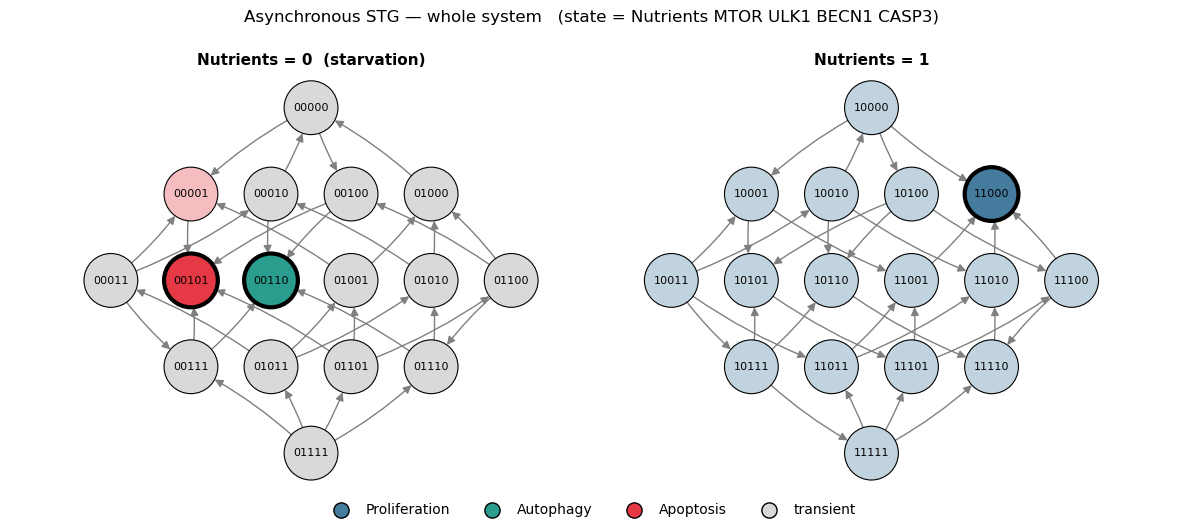

In [5]:
def label(state):
    d = dict(zip(free, state))
    if d["BECN1"] and not d["CASP3"]: return "Autophagy"
    if d["CASP3"] and not d["BECN1"]: return "Apoptosis"
    if d["MTOR"]: return "Proliferation"
    return "transient"

attractors = [sorted(a) for a in nx.attracting_components(stg)]
att_states = {s for a in attractors for s in a}
basin = {s: [i for i, a in enumerate(attractors) if any(nx.has_path(stg, s, t) for t in a)] for s in stg}

# lay each Nutrients half out by number of active nodes (Hamming layers)
pos_stg = {}
for nut, x0 in [(0, -3.5), (1, 3.5)]:
    layers = {}
    for s in stg:
        if s[0] == nut: layers.setdefault(sum(s[1:]), []).append(s)
    pos_stg.update({s: (x0 + i - (len(L) - 1) / 2, -k) for k, L in layers.items() for i, s in enumerate(sorted(L))})

colors = []
for s in stg:
    if s in att_states: colors.append(PHENO[label(s)])
    elif len(basin[s]) == 1: colors.append(PHENO[label(attractors[basin[s][0]][0])] + "55")
    else: colors.append(PHENO["transient"])

fig, ax = plt.subplots(figsize=(15, 6))
nx.draw_networkx_edges(stg, pos_stg, node_size=1500, edge_color="grey", arrowsize=12, ax=ax,
                       connectionstyle="arc3,rad=0.08")
nx.draw_networkx_nodes(stg, pos_stg, node_size=1500, node_color=colors, edgecolors="black",
                       linewidths=[3 if s in att_states else 0.8 for s in stg], ax=ax)
nx.draw_networkx_labels(stg, pos_stg, {s: "".join(map(str, s)) for s in stg}, font_size=8, ax=ax)
for x0, t in [(-3.5, "Nutrients = 0  (starvation)"), (3.5, "Nutrients = 1")]:
    ax.text(x0, 0.55, t, ha="center", va="center", fontsize=11, fontweight="bold")
ax.set_ylim(-4.45, 0.9)
for name in ["Proliferation", "Autophagy", "Apoptosis", "transient"]:
    ax.scatter([], [], c=PHENO[name], s=120, edgecolors="black", label=name)
ax.legend(loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.08))
ax.set_title(f"Asynchronous STG — whole system   (state = {' '.join(free)})")
ax.axis("off")
fig.savefig("figures/2_state_transition_graph.png", dpi=300, bbox_inches="tight")

## 3. Attractors per scenario

In [6]:
bn = mpbn.MPBooleanNetwork("toy_model.bnet")
rows = []
for scenario, nut in {"Nutrients ON": 1, "Starvation": 0}.items():
    bn["Nutrients"] = nut
    for i, a in enumerate(bn.attractors()):
        rows.append({"scenario": scenario, "attractor": f"{scenario} #{i+1}", **{n: a[n] for n in nodes}})
bn["Nutrients"] = "Nutrients"
att = pd.DataFrame(rows).set_index("attractor")
att

,scenario,Nutrients,MTOR,ULK1,BECN1,CASP3
attractor,,,,,,
Nutrients ON #1,Nutrients ON,1,1,0,0,0
Starvation #1,Starvation,0,0,1,1,0
Starvation #2,Starvation,0,0,1,0,1


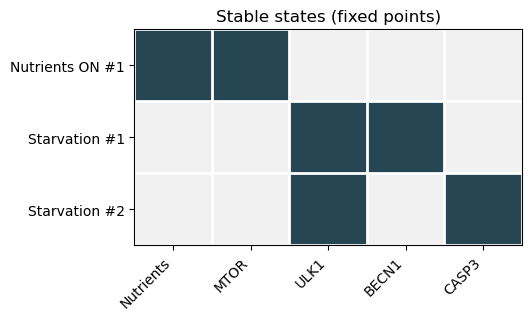

In [7]:
mat = att[nodes].astype(int)
fig, ax = plt.subplots(figsize=(5, 0.6 * len(mat) + 1))
ax.imshow(mat.values, cmap=plt.matplotlib.colors.ListedColormap(["#f1f1f1", "#264653"]), aspect="auto")
ax.set_xticks(range(len(nodes)), nodes, rotation=45, ha="right")
ax.set_yticks(range(len(mat)), mat.index)
ax.set_xticks(np.arange(-.5, len(nodes)), minor=True); ax.set_yticks(np.arange(-.5, len(mat)), minor=True)
ax.grid(which="minor", color="white", linewidth=2); ax.tick_params(which="minor", length=0)
ax.set_title("Stable states (fixed points)")
fig.savefig("figures/3_attractors.png", dpi=300, bbox_inches="tight")

## 4. MaBoSS stochastic simulation

In [8]:
sim = maboss.loadBNet("toy_model.bnet")
sim.update_parameters(max_time=10, time_tick=0.1, sample_count=5000, thread_count=4)
for n in nodes:
    sim.network.set_istate(n, [0.5, 0.5])
sim.network.set_output(["MTOR", "BECN1", "CASP3"])

results = {}
for scenario, nut in {"Nutrients ON": 1, "Starvation": 0}.items():
    s = sim.copy()
    s.network.set_istate("Nutrients", [1 - nut, nut])
    results[scenario] = s.run()

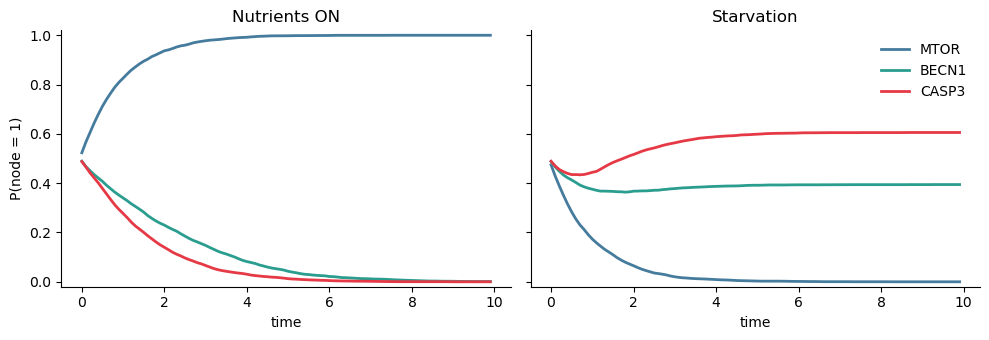

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, (scenario, res) in zip(axes, results.items()):
    nt = res.get_nodes_probtraj()
    for n, c in [("MTOR", PHENO["Proliferation"]), ("BECN1", PHENO["Autophagy"]), ("CASP3", PHENO["Apoptosis"])]:
        ax.plot(nt.index, nt[n], color=c, lw=2, label=n)
    ax.set_title(scenario); ax.set_xlabel("time"); ax.set_ylim(-0.02, 1.02)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("P(node = 1)"); axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig("figures/4_maboss_trajectories.png", dpi=300, bbox_inches="tight")

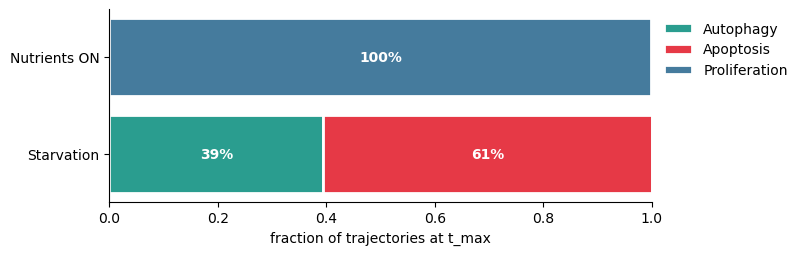

In [10]:
names = {"MTOR": "Proliferation", "BECN1": "Autophagy", "CASP3": "Apoptosis"}
final = pd.DataFrame({sc: r.get_last_states_probtraj().iloc[0] for sc, r in results.items()}).fillna(0)
final = final.rename(index=lambda k: names.get(k, k)).T
final = final.loc[:, final.max() > 0.005]

fig, ax = plt.subplots(figsize=(7, 2.5))
left = np.zeros(len(final))
for ph in final.columns:
    v = final[ph].values
    ax.barh(final.index, v, left=left, color=PHENO.get(ph, PHENO["transient"]), edgecolor="white", lw=2, label=ph)
    for y, (l, w) in enumerate(zip(left, v)):
        if w > 0.05: ax.text(l + w / 2, y, f"{w:.0%}", ha="center", va="center", color="white", fontweight="bold")
    left += v
ax.set_xlim(0, 1); ax.invert_yaxis(); ax.set_xlabel("fraction of trajectories at t_max")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc="upper left")
fig.savefig("figures/5_maboss_final_states.png", dpi=300, bbox_inches="tight")